Total number of images: 1797
Total number of labels: 1797
Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3598 - loss: 2.1549 - val_accuracy: 0.7972 - val_loss: 1.5140
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8101 - loss: 1.2396 - val_accuracy: 0.9111 - val_loss: 0.6041
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8959 - loss: 0.5415 - val_accuracy: 0.9250 - val_loss: 0.3329
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9410 - loss: 0.3127 - val_accuracy: 0.9361 - val_loss: 0.2416
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9513 - loss: 0.2325 - val_accuracy: 0.9333 - val_loss: 0.2118
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9524 - loss: 0.1860 - val_accuracy: 0.9528 - val_loss: 0.1651
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9716 - loss: 0.1348 - val_accuracy: 0.9583 - val_loss: 0.1533
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accu

Saving pic7.jpg to pic7.jpg


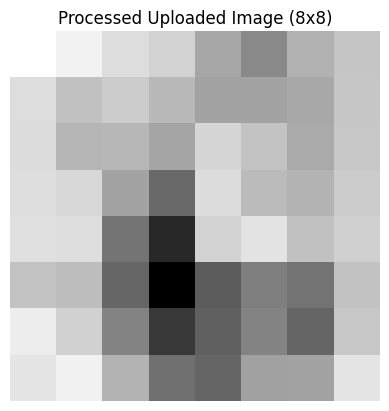

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Digit: 9


In [3]:

# CNN based Object recognition (Digit Classification)

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from google.colab import files
from skimage.transform import resize

# Load dataset
digits = load_digits()
X = digits.images
y = digits.target

print("Total number of images:", X.shape[0])
print("Total number of labels:", y.shape[0])

# Normalize and reshape for CNN
X = X / 16.0
X = X.reshape(-1, 8, 8, 1)

y = to_categorical(y, 10)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(8,8,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Model Accuracy:", accuracy)

# Upload image
uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

# Convert to grayscale
if len(img.shape) == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img

# Resize to 8x8
img_resized = resize(img_gray, (8, 8), anti_aliasing=True)

# Normalize & invert
img_resized = img_resized / img_resized.max()
img_resized = 1 - img_resized

plt.imshow(img_resized, cmap='gray')
plt.title("Processed Uploaded Image (8x8)")
plt.axis('off')
plt.show()

# Prepare for prediction
img_resized = img_resized.reshape(1, 8, 8, 1)

prediction = model.predict(img_resized)
print("Predicted Digit:", np.argmax(prediction))